In [6]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("IPG2211A2N.csv")

In [3]:
# Convert 'observation_date' to datetime and set as index
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df.set_index('observation_date')
df.head()

,IPG2211A2N
observation_date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608


In [4]:
from statsmodels.tsa.arima.model import ARIMA

# Select the time series column
time_series = df['IPG2211A2N']

# Fit an ARMA model (p=1, d=0, q=1)
# Note: ARMA is a special case of ARIMA where d=0 (no differencing)
# The order (p,d,q) represents (AR order, Differencing order, MA order)
model = ARIMA(time_series, order=(2, 0, 2))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                 1047
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -3053.748
Date:                Tue, 12 May 2026   AIC                           6119.496
Time:                        11:41:45   BIC                           6149.218
Sample:                    01-01-1939   HQIC                          6130.768
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.6370     50.331      1.145      0.252     -41.009     156.283
ar.L1          1.3447      0.034     39.680      0.000       1.278       1.411
ar.L2         -0.3448      0.034    -10.199      0.0

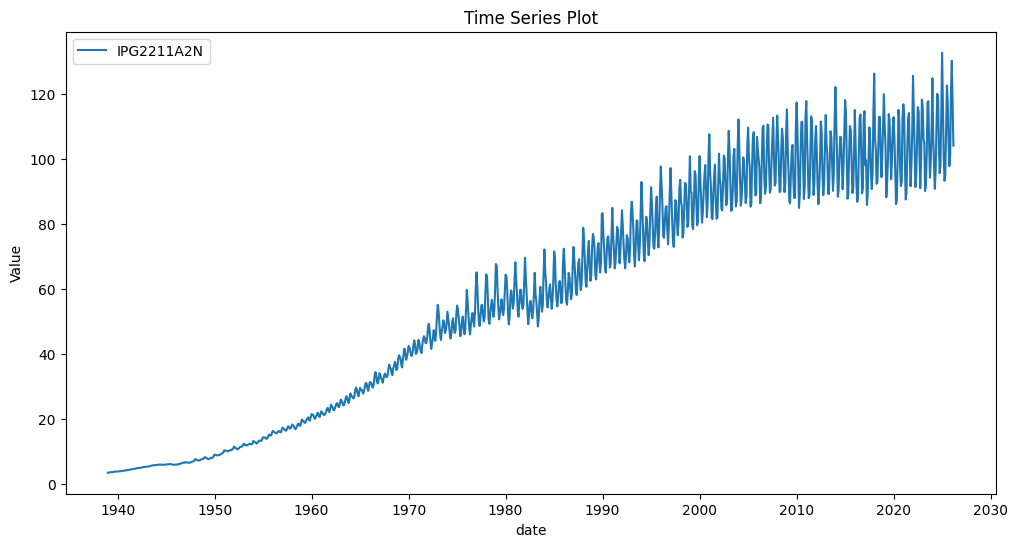

ADF Statistic: -0.513073
p-value: 0.889440
-> Nicht stationär, Differenzierung nötig


In [5]:
# Zeitreihe auswählen
time_series = df['IPG2211A2N']

# Zeitreihe visuell darstellen um Trend und Muster zu erkennen
plt.figure(figsize=(12, 6))
plt.plot(time_series, label='IPG2211A2N')
plt.xlabel('date')
plt.ylabel('Value')
plt.title('Time Series Plot')
plt.legend()
plt.show()

# ADF-Test zur Prüfung ob die Zeitreihe stationär ist
# H0: Zeitreihe ist nicht stationär
# p-value < 0.05 -> stationär, p-value > 0.05 -> nicht stationär
result = adfuller(time_series)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
if result[1] > 0.05:
    print("-> Nicht stationär, Differenzierung nötig")
else:
    print("-> Stationär")



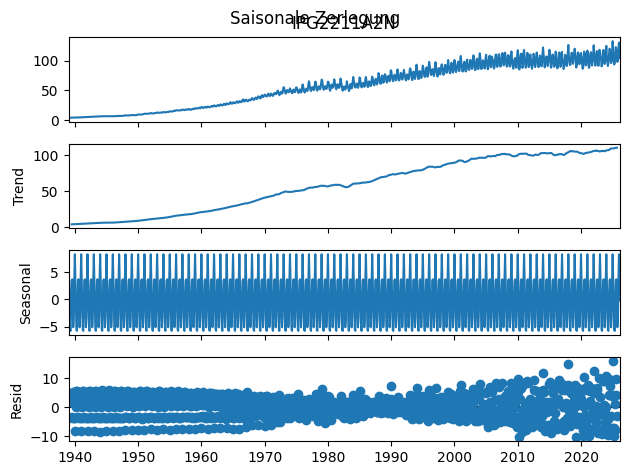

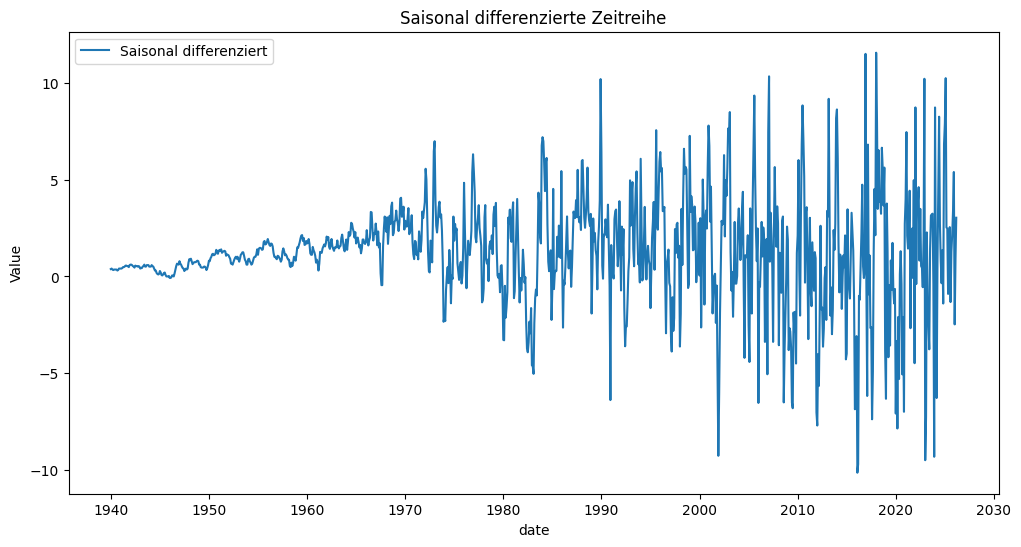

ADF nach saisonaler Differenzierung: -7.074056211330275
p-value: 4.853279152100396e-10
-> Jetzt stationär


In [8]:
# Zeitreihe in Trend, Saisonalität und Residuen zerlegen
# period=12 da monatliche Daten (12 Monate = 1 Jahr)
decomposition = seasonal_decompose(time_series, model='additive', period=12)
decomposition.plot()
plt.suptitle('Saisonale Zerlegung')
plt.show()

# Saisonale Differenzierung um Periodizität zu entfernen
# diff(12) subtrahiert den Wert vom Vorjahresmonat
time_series_seasonal_diff = time_series.diff(12).dropna()

plt.figure(figsize=(12,6))
plt.plot(time_series_seasonal_diff, label='Saisonal differenziert')
plt.xlabel('date')
plt.ylabel('Value')
plt.title('Saisonal differenzierte Zeitreihe')
plt.legend()
plt.show()

# ADF-Test nach saisonaler Differenzierung zur Kontrolle
result_sd = adfuller(time_series_seasonal_diff)
print('ADF nach saisonaler Differenzierung:', result_sd[0])
print('p-value:', result_sd[1])
if result_sd[1] > 0.05:
    print("-> Immer noch nicht stationär")
else:
    print("-> Jetzt stationär")


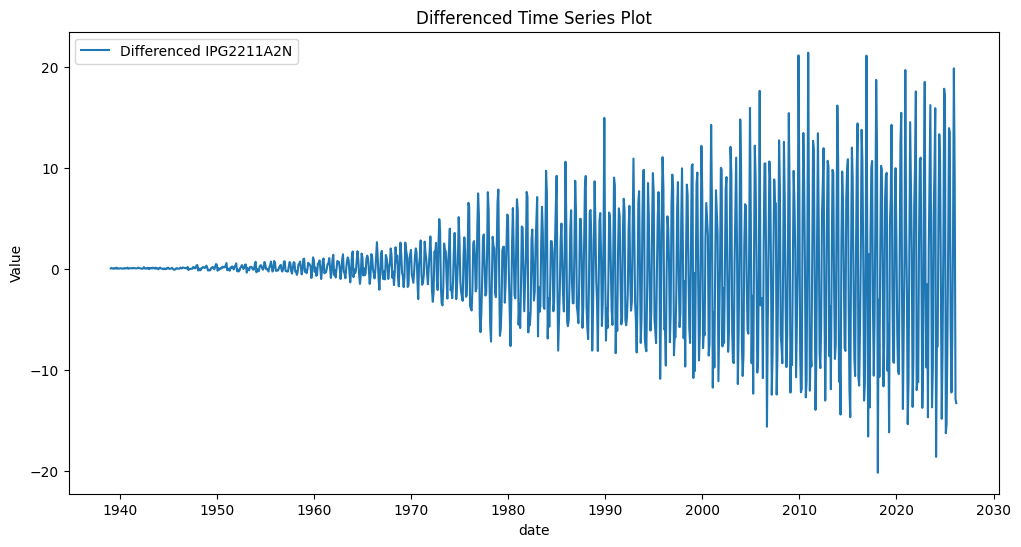

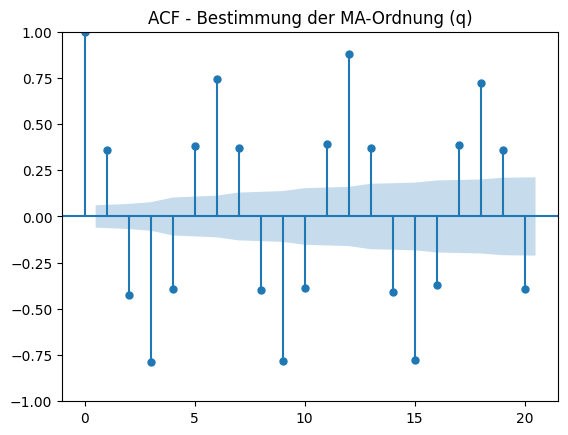

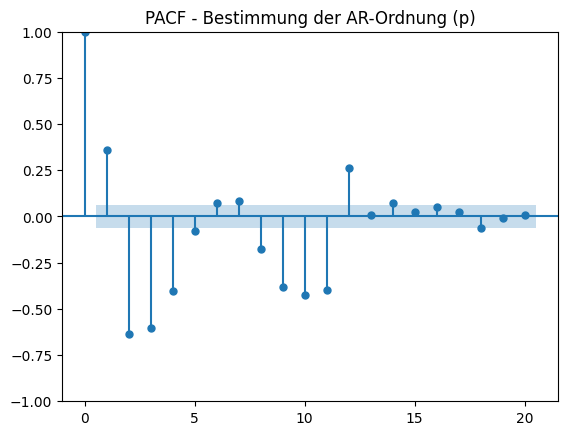

In [9]:
# Erste Differenzierung um den Trend zu entfernen (d=1)
time_series_diff = time_series.diff().dropna()

# Differenzierte Zeitreihe plotten zur visuellen Kontrolle
plt.figure(figsize=(12, 6))
plt.plot(time_series_diff, label='Differenced IPG2211A2N')
plt.xlabel('date')
plt.ylabel('Value')
plt.title('Differenced Time Series Plot')
plt.legend()
plt.show()

# ACF: zeigt bei welchem Lag die Autokorrelation abschneidet -> MA-Ordnung q
# PACF: zeigt bei welchem Lag die partielle Autokorrelation abschneidet -> AR-Ordnung p
plot_acf(time_series_diff, lags=20)
plt.title('ACF - Bestimmung der MA-Ordnung (q)')
plot_pacf(time_series_diff, lags=20)
plt.title('PACF - Bestimmung der AR-Ordnung (p)')
plt.show()

In [10]:
# Daten in 80% Training und 20% Test aufteilen
# Train: Modell wird damit trainiert
# Test: Modell wird damit bewertet (ungesehene Daten)
train_size = int(len(time_series) * 0.8)    
train, test = time_series[0:train_size], time_series[train_size:]

print(f'Trainingsdaten: {len(train)} Datenpunkte')
print(f'Testdaten: {len(test)} Datenpunkte')

Trainingsdaten: 837 Datenpunkte
Testdaten: 210 Datenpunkte


In [11]:
# Systematische Suche nach den besten ARIMA-Parametern (p, q)
# d=1 ist fest, da wir bereits eine Differenzierung durchgeführt haben
# Optimierungskriterium: MSE auf den Testdaten (wie in der Aufgabe verlangt)

best_mse = np.inf
best_order = None

for p in range(5):
    for q in range(5):
        try:
            # Modell mit aktuellen p, q Werten trainieren
            model = ARIMA(train, order=(p, 1, q))
            result = model.fit()

            # Prognose auf Testdaten
            forecast_grid = result.forecast(steps=len(test))

            # MSE berechnen und mit bestem bisherigen Wert vergleichen
            mse = mean_squared_error(test, forecast_grid)
            if mse < best_mse:
                best_mse = mse
                best_order = (p, 1, q)
        except:
            continue

print("Beste Parameter:", best_order)
print("Bester MSE:", best_mse)

c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency in

Beste Parameter: (3, 1, 3)
Bester MSE: 39.97088226110372


c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
# Finales ARIMA-Modell mit den besten gefundenen Parametern trainieren
model = ARIMA(train, order=best_order)
model_fit = model.fit()

# Modellzusammenfassung ausgeben (Koeffizienten, Gütekriterien etc.)
print(model_fit.summary())

c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                  837
Model:                 ARIMA(3, 1, 3)   Log Likelihood               -1794.667
Date:                Tue, 12 May 2026   AIC                           3603.334
Time:                        11:45:58   BIC                           3636.434
Sample:                    01-01-1939   HQIC                          3616.023
                         - 09-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0209      0.020      1.029      0.304      -0.019       0.061
ar.L2         -0.0201      0.020     -0.988      0.323      -0.060       0.020
ar.L3         -0.9791      0.020    -48.214      0.0

c:\Users\nicob\anaconda3\envs\Nicolas\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
# Prognose für den Testzeitraum erstellen
# steps=len(test) -> so viele Schritte wie Testdaten vorhanden
forecast = model_fit.forecast(steps=len(test))

In [14]:
# MSE des finalen Modells berechnen
# Vergleich der echten Testwerte mit den prognostizierten Werten
mse = mean_squared_error(test, forecast)
print(f'Mean Squared Error des ARIMA{best_order} Modells: {mse:.4f}')

Mean Squared Error des ARIMA(3, 1, 3) Modells: 39.9709


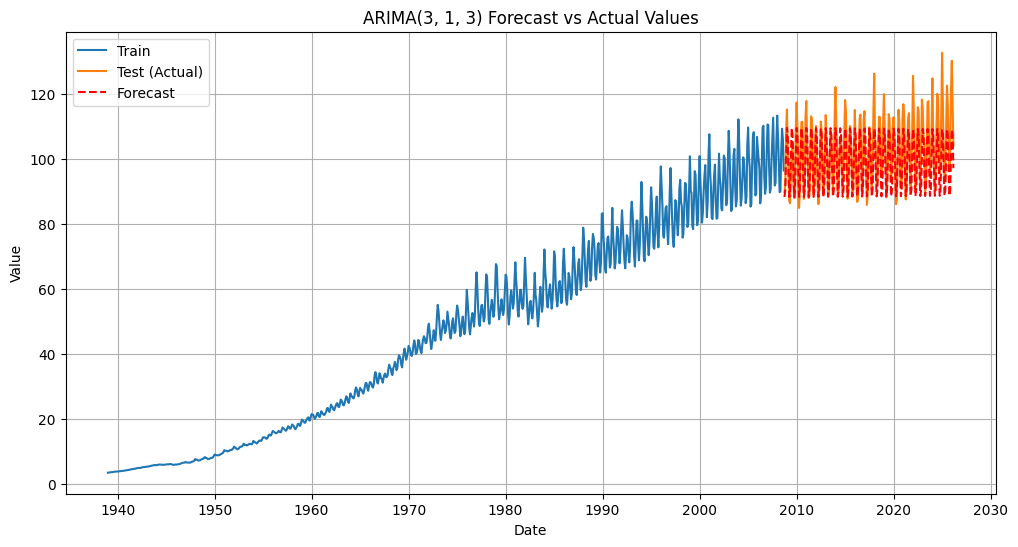

In [15]:
# Trainingsdaten, echte Testwerte und Prognose visualisieren
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test (Actual)')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Value')
plt.title(f'ARIMA{best_order} Forecast vs Actual Values')

plt.legend()
plt.grid(True)
plt.show()